# กำหนด ROI แถวเสาจากกล้องด้านข้าง

ไฟล์นี้ใช้เลือกภาพจากวิดีโอและกำหนดพื้นที่สนใจ (ROI) ของแต่ละแถวเสา เช่น R01, R02 ด้วยกรอบสี่เหลี่ยมบน Google Colab เพื่อนำค่าพิกัดไปใช้ในโค้ดตรวจจับการเทคอนกรีต

รันเซลล์ตามลำดับจากบนลงล่าง และกำหนด ROI ทีละมุมกล้อง


## 1. เชื่อมต่อ Google Drive

เชื่อมต่อ Google Drive เพื่อให้ Colab อ่านวิดีโอที่เก็บไว้ในไดรฟ์ได้ เมื่อระบบขอสิทธิ์ ให้เลือกบัญชีที่เก็บวิดีโอ


In [18]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. ระบุพาธวิดีโอ

ตัวแปร `video_path` ระบุตำแหน่งวิดีโอที่ต้องการใช้งาน ตัวอย่างในไฟล์คือ `/content/drive/MyDrive/Video_PRO/side.mp4`

ไฟล์นี้มีการระบุพาธซ้ำในขั้นตอนเลือกภาพและขั้นตอนระบุวิดีโอสองมุมกล้อง หากใช้ไฟล์วิดีโออื่น ให้ตรวจสอบพาธในแต่ละขั้นตอนให้ตรงกัน


In [19]:
video_path = "/content/drive/MyDrive/Video_PRO/side.mp4"

## 3. ตรวจสอบวิดีโอ

เปิดวิดีโอเพื่อตรวจสอบว่าอ่านไฟล์ได้ พร้อมแสดงความกว้าง ความสูง อัตราเฟรม (FPS) และจำนวนเฟรมทั้งหมด


In [20]:
import cv2

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ เปิดวิดีโอไม่ได้")
else:
    print("✅ เปิดวิดีโอสำเร็จ")

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print("ขนาดวิดีโอ =", width, "x", height)
    print("FPS =", fps)
    print("จำนวนเฟรม =", frame_count)

cap.release()

✅ เปิดวิดีโอสำเร็จ
ขนาดวิดีโอ = 1280 x 720
FPS = 30.0
จำนวนเฟรม = 100680


## 4. เลือกภาพตามเวลาเป็นวินาที

ดึงภาพจากเวลาที่ระบุใน `time_sec` ตัวอย่างนี้ใช้วินาทีที่ 10 ภาพที่อ่านได้จะเก็บในตัวแปร `img` และแสดงเพื่อใช้ตรวจสอบพื้นที่เสา


ขนาดเฟรม = (720, 1280, 3)


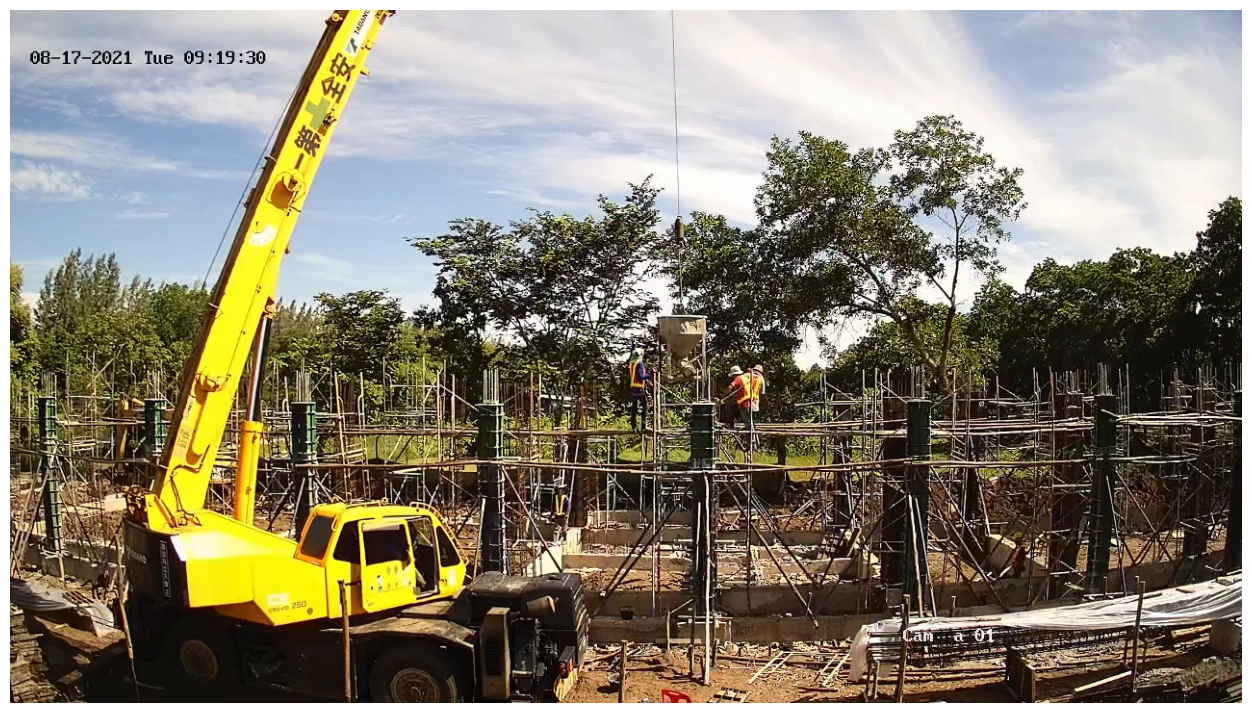

In [21]:
import cv2
import matplotlib.pyplot as plt

video_path = "/content/drive/MyDrive/Video_PRO/side.mp4"

cap = cv2.VideoCapture(video_path)

# เลือกเวลาที่ต้องการ เช่น วินาทีที่ 10
time_sec = 10

cap.set(cv2.CAP_PROP_POS_MSEC, time_sec * 1000)

ret, frame = cap.read()

cap.release()

if ret:
    print("ขนาดเฟรม =", frame.shape)

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 9))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

else:
    print("❌ ดึงเฟรมไม่ได้")

## 5. เลือกภาพตามนาทีและวินาที

เลือกเวลาโดยระบุ `minute` และ `second` ตัวอย่างนี้ใช้เวลา 12 นาที 30 วินาที หากอ่านภาพสำเร็จ ภาพนี้จะเป็น `img` ที่ใช้กำหนด ROI แทนภาพจากขั้นตอนก่อนหน้า

เลือกภาพที่เห็นแถวเสาชัดเจนก่อนเปิดเครื่องมือกำหนด ROI


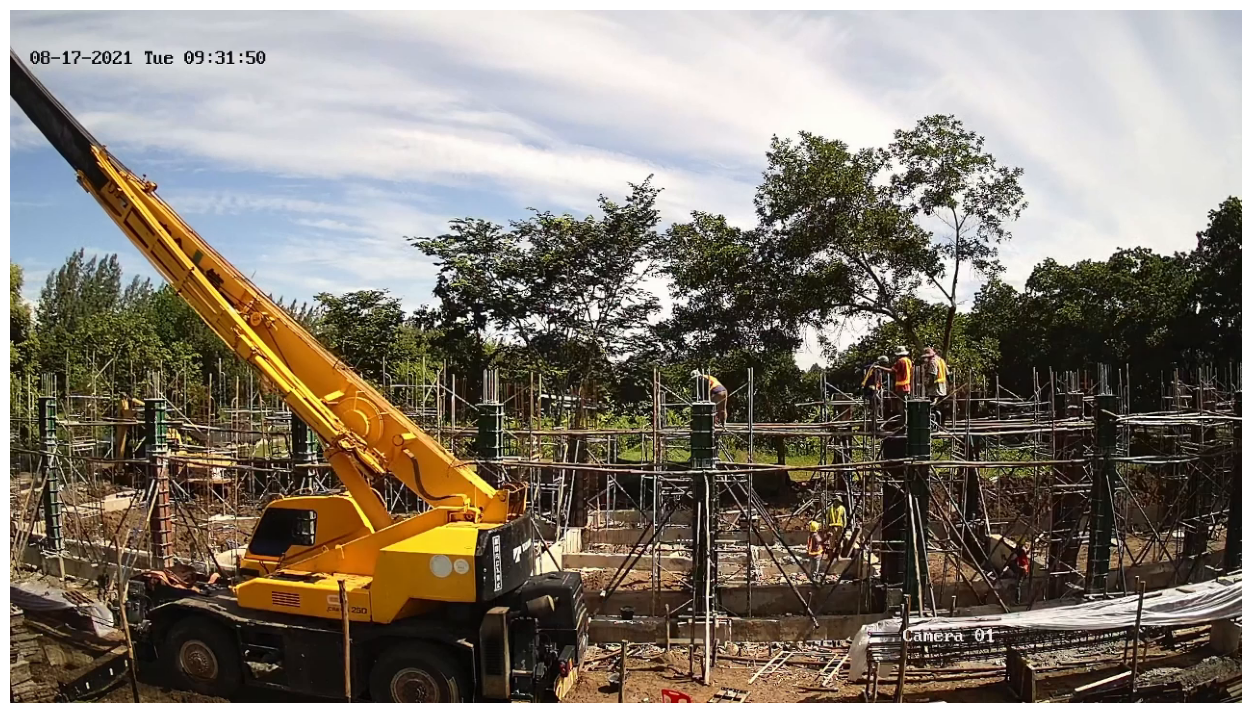

In [22]:
minute = 12
second = 30

time_sec = minute * 60 + second

cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_MSEC, time_sec * 1000)

ret, frame = cap.read()
cap.release()

if ret:
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 9))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

## 6. ระบุวิดีโอของแต่ละมุมกล้อง

ตัวแปร `video_top` เก็บพาธวิดีโอมุมด้านบนหรือด้านหน้า ส่วน `video_side` เก็บพาธวิดีโอมุมด้านข้าง


In [23]:
video_top = "/content/drive/MyDrive/Video_PRO/front.mp4"
video_side = "/content/drive/MyDrive/Video_PRO/side.mp4"

## 7. เลือกมุมกล้องด้านข้าง

เซลล์นี้กำหนด `video_path` ให้ใช้วิดีโอด้านข้างสำหรับกำหนด Row โดยไม่ได้ดึงภาพใหม่ ภาพที่เครื่องมือใช้ยังเป็น `img` จากขั้นตอนเลือกภาพก่อนหน้า


In [25]:
# # กล้องด้านบน → Column
# video_path = video_top

# กล้องด้านข้าง → Row
video_path = video_side

## 8. กำหนด ROI ของแต่ละ Row

รันเซลล์ด้านล่างเพื่อเปิดเครื่องมือ แล้วทำตามขั้นตอนดังนี้

1. เลือกหมายเลข **Row** เช่น 1 หมายถึง R01
2. ปรับ `x1, y1` เป็นมุมซ้ายบน และ `x2, y2` เป็นมุมขวาล่างของกรอบ โดย `x2 > x1` และ `y2 > y1`
3. กด **บันทึก Row** เพื่อเก็บพิกัดของแถวนั้น
4. เปลี่ยนหมายเลข Row และกำหนดกรอบจนครบทุกแถว
5. กด **ดูทั้งหมด** เพื่อตรวจสอบกรอบ หรือเลือกหมายเลขแล้วกด **ลบ Row** เพื่อลบกรอบที่บันทึกไว้
6. กด **แสดงค่าพิกัด** แล้วคัดลอก `row_rois` ไปใช้ในโค้ดหลัก

ขณะปรับกรอบ กรอบสีแดงคือกรอบปัจจุบัน และกรอบสีเขียวคือกรอบที่บันทึกไว้แล้ว ค่าของแต่ละแถวอยู่ในรูปแบบ `[x1, y1, x2, y2]`

ปุ่ม **บันทึก Row** เก็บค่าไว้ในตัวแปรระหว่างใช้งาน จึงควรคัดลอกค่าพิกัดก่อนปิดเซสชันหรือรันเซลล์เครื่องมือนี้ใหม่ ซึ่งจะเริ่ม `row_rois` เป็นค่าว่าง


In [26]:
import cv2
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# img = ภาพที่ดึงจากวิดีโอ side.mp4
H, W = img.shape[:2]

# เก็บ ROI ของแต่ละแถว
row_rois = {}

# =========================
# เลือกหมายเลข Row
# =========================
row_input = widgets.BoundedIntText(
    value=1,
    min=1,
    max=50,
    description="Row:"
)

# =========================
# Slider พิกัดกรอบ
# =========================
x1_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=W-1,
    description="x1",
    continuous_update=False
)

y1_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=H-1,
    description="y1",
    continuous_update=False
)

x2_slider = widgets.IntSlider(
    value=min(300, W-1),
    min=0,
    max=W-1,
    description="x2",
    continuous_update=False
)

y2_slider = widgets.IntSlider(
    value=min(200, H-1),
    min=0,
    max=H-1,
    description="y2",
    continuous_update=False
)

# =========================
# ปุ่ม
# =========================
save_button = widgets.Button(
    description="บันทึก Row",
    button_style="success"
)

show_all_button = widgets.Button(
    description="ดูทั้งหมด",
    button_style="info"
)

print_button = widgets.Button(
    description="แสดงค่าพิกัด",
    button_style="warning"
)

delete_button = widgets.Button(
    description="ลบ Row",
    button_style="danger"
)

output = widgets.Output()


def get_row_name():
    return f"R{row_input.value:02d}"


# =========================
# แสดง Preview
# =========================
def preview(change=None):

    name = get_row_name()

    x1 = x1_slider.value
    y1 = y1_slider.value
    x2 = x2_slider.value
    y2 = y2_slider.value

    vis = img.copy()

    # กรอบที่บันทึกแล้ว = เขียว
    for row_name, bbox in row_rois.items():

        bx1, by1, bx2, by2 = bbox

        cv2.rectangle(
            vis,
            (bx1, by1),
            (bx2, by2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            vis,
            row_name,
            (bx1, max(20, by1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    # กรอบที่กำลังปรับ = แดง
    cv2.rectangle(
        vis,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

    cv2.putText(
        vis,
        name,
        (x1, max(20, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 0),
        2
    )

    with output:

        clear_output(wait=True)

        plt.figure(figsize=(16, 9))
        plt.imshow(vis)
        plt.axis("off")
        plt.show()

        print(f"{name}: [{x1}, {y1}, {x2}, {y2}]")


# =========================
# บันทึก Row
# =========================
def save_row(button):

    name = get_row_name()

    x1 = x1_slider.value
    y1 = y1_slider.value
    x2 = x2_slider.value
    y2 = y2_slider.value

    if x2 <= x1 or y2 <= y1:
        with output:
            print("❌ x2 ต้องมากกว่า x1 และ y2 ต้องมากกว่า y1")
        return

    row_rois[name] = [
        x1,
        y1,
        x2,
        y2
    ]

    preview()

    with output:
        print("✅ บันทึก", name)


# =========================
# ลบ Row
# =========================
def delete_row(button):

    name = get_row_name()

    if name in row_rois:
        del row_rois[name]

    preview()


# =========================
# ดูกรอบทั้งหมด
# =========================
def show_all(button):

    vis = img.copy()

    for name, (x1, y1, x2, y2) in row_rois.items():

        cv2.rectangle(
            vis,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            3
        )

        cv2.putText(
            vis,
            name,
            (x1, max(20, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 0),
            2
        )

    with output:

        clear_output(wait=True)

        plt.figure(figsize=(16, 9))
        plt.imshow(vis)
        plt.axis("off")
        plt.show()

        print("จำนวน Row =", len(row_rois))


# =========================
# แสดง Dictionary
# =========================
def print_rois(button):

    with output:

        clear_output()

        print("row_rois = {")

        for name, bbox in sorted(row_rois.items()):
            print(f'    "{name}": {bbox},')

        print("}")


# =========================
# เชื่อม Slider
# =========================
for slider in [
    x1_slider,
    y1_slider,
    x2_slider,
    y2_slider
]:
    slider.observe(
        preview,
        names="value"
    )

row_input.observe(
    preview,
    names="value"
)

save_button.on_click(save_row)
delete_button.on_click(delete_row)
show_all_button.on_click(show_all)
print_button.on_click(print_rois)


# =========================
# แสดงเครื่องมือ
# =========================
display(
    row_input,

    x1_slider,
    y1_slider,
    x2_slider,
    y2_slider,

    widgets.HBox([
        save_button,
        delete_button,
        show_all_button,
        print_button
    ]),

    output
)

preview()

BoundedIntText(value=1, description='Row:', max=50, min=1)

IntSlider(value=0, continuous_update=False, description='x1', max=1279)

IntSlider(value=0, continuous_update=False, description='y1', max=719)

IntSlider(value=300, continuous_update=False, description='x2', max=1279)

IntSlider(value=200, continuous_update=False, description='y2', max=719)

Output()